# SVM - Model Evaluation

Evaluación de modelos SVM (BALANCED vs RAW) usando validación cruzada estratificada.

## 1. Imports

In [12]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_fscore_support, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score
)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
print("✓ Libraries imported")

✓ Libraries imported


## 2. Load Data and Models

In [13]:
BASE_PATH = Path('../../..').resolve()
DATA_PATH = BASE_PATH / 'data' / 'processed' / 'pickle'
MODELS_PATH = BASE_PATH / 'models' / 'svm'
RESULTS_PATH = BASE_PATH / 'data' / 'results' / 'svm'
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

# Cargamos X_train y y_train (datos reales sin alterar) PARA EL CROSS VALIDATION
with open(DATA_PATH / 'X_train_raw.pkl', 'rb') as f:
    X_train_raw = pickle.load(f)
with open(DATA_PATH / 'y_train_raw.pkl', 'rb') as f:
    y_train_raw = pickle.load(f)

if isinstance(X_train_raw, pd.DataFrame): X_train_raw = X_train_raw.values
if isinstance(y_train_raw, pd.DataFrame): y_train_raw = y_train_raw.iloc[:, 0]

# Apuntamos y_test al y_train_raw para el resto del notebook
y_test = y_train_raw

# Load models (Solo para extraer sus hiperparámetros)
with open(MODELS_PATH / 'modelo_svm_balanced.pkl', 'rb') as f:
    model_balanced = pickle.load(f)
with open(MODELS_PATH / 'modelo_svm_raw.pkl', 'rb') as f:
    model_raw = pickle.load(f)

print(f"✓ Data for CV loaded: shape     : {X_train_raw.shape}")
print(f"✓ Class distribution : {dict(pd.Series(y_train_raw).value_counts().sort_index())}")
print(f"✓ Models loaded")

✓ Data for CV loaded: shape     : (699, 651)
✓ Class distribution : {0: np.int64(633), 1: np.int64(66)}
✓ Models loaded


## 3. Generate Predictions

In [14]:
print("Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para SVM...\n")

# Extraemos TODOS los parámetros del modelo guardado (ya incluye random_state)
TRACKED_PARAMS = ['C', 'kernel', 'degree', 'gamma', 'coef0', 'class_weight',
                  'decision_function_shape', 'probability', 'random_state']
params_balanced = {k: v for k, v in model_balanced.get_params().items() if k in TRACKED_PARAMS}
params_raw   = {k: v for k, v in model_raw.get_params().items()   if k in TRACKED_PARAMS}

# Para el modelo RAW, aseguramos class_weight='balanced'
if 'class_weight' not in params_raw or params_raw['class_weight'] is None:
    params_raw['class_weight'] = 'balanced'

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 1. PREDICCIONES CV MODELO RAW (con escalado en el pipeline) ---
# NOTA: NO pasamos random_state=42 explícito, ya viene en params_raw
cv_model_raw = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(**params_raw))
])
print("  Calculando predicciones CV para RAW...")
y_pred_raw   = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict', n_jobs=-1)
y_proba_raw  = cross_val_predict(cv_model_raw, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

# --- 2. PREDICCIONES CV MODELO ADASYN (PIPELINE con escalado) ---
# Para BALANCED no usamos class_weight='balanced' para no doble-ponderar
params_balanced['class_weight'] = None

# NOTA: NO pasamos random_state=42 explícito, ya viene en params_balanced
cv_model_adasyn = SVC(**params_balanced)
adasyn_cv = ADASYN(sampling_strategy='auto', random_state=42, n_neighbors=5)
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('adasyn', adasyn_cv),
    ('svm',    cv_model_adasyn)
])

print("  Calculando predicciones CV para ADASYN (Pipeline)...")
y_pred_balanced  = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict', n_jobs=-1)
y_proba_balanced = cross_val_predict(pipeline, X_train_raw, y_train_raw, cv=outer_cv, method='predict_proba', n_jobs=-1)

print("\n✓ Predicciones CV finalizadas. \nAhora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.")

Generando predicciones Out-of-Fold usando 5-Fold Stratified CV para SVM...

  Calculando predicciones CV para RAW...


  Calculando predicciones CV para ADASYN (Pipeline)...

✓ Predicciones CV finalizadas. 
Ahora el resto del notebook calculará TODAS las métricas sobre estos resultados realistas.


## 4. Overall Metrics

In [15]:
print("" + "="*70)
print("OVERALL MODEL METRICS")
print("="*70)

overall_metrics = {
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
               'F1-Score (macro)', "Cohen's Kappa"],
    'BALANCED': [
        f"{accuracy_score(y_test, y_pred_balanced):.4f}",
        f"{precision_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_balanced, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_balanced):.4f}",
    ],
    'RAW': [
        f"{accuracy_score(y_test, y_pred_raw):.4f}",
        f"{precision_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{recall_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{f1_score(y_test, y_pred_raw, average='macro', zero_division=0):.4f}",
        f"{cohen_kappa_score(y_test, y_pred_raw):.4f}",
    ]
}

df_overall = pd.DataFrame(overall_metrics)
print("" + df_overall.to_string(index=False))

OVERALL MODEL METRICS
           Metric BALANCED    RAW
         Accuracy   0.8598 0.6352
Precision (macro)   0.5984 0.5511
   Recall (macro)   0.6037 0.6425
 F1-Score (macro)   0.6009 0.5055
    Cohen's Kappa   0.2018 0.1179


### 4.1 Overall Metrics - Visualization

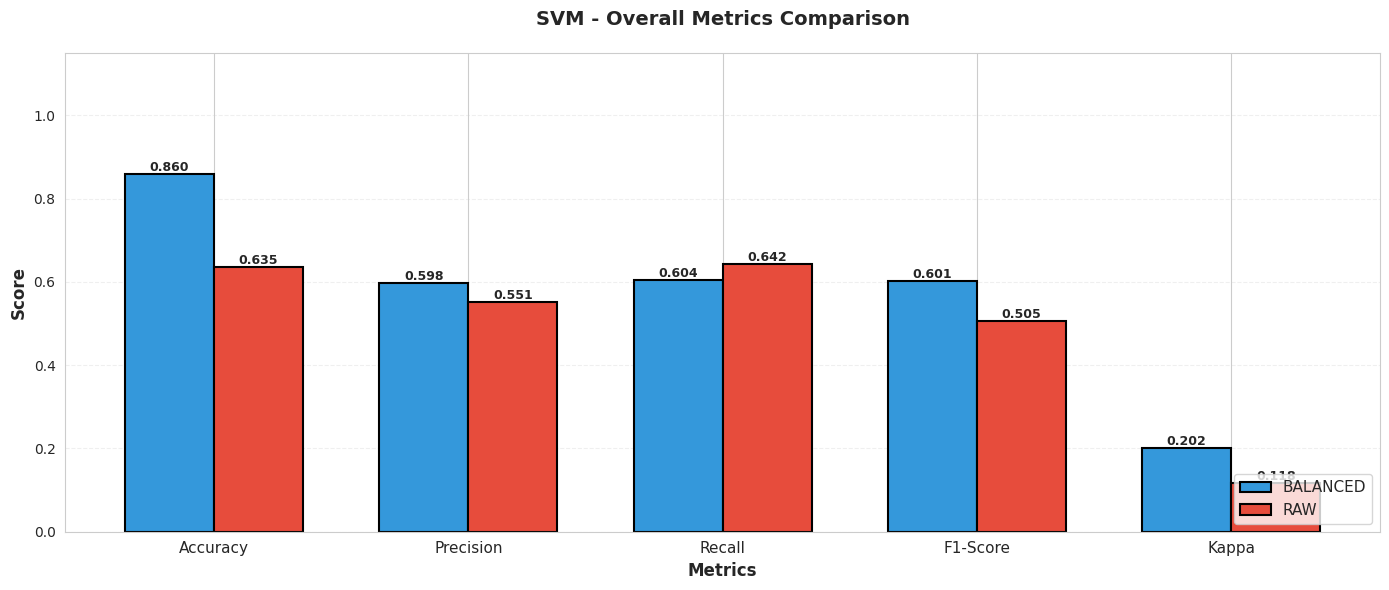

✓ Plot saved


In [16]:
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', "Kappa"]
balanced_vals = [float(x) for x in df_overall['BALANCED'].values]
raw_vals   = [float(x) for x in df_overall['RAW'].values]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, balanced_vals, width, label='BALANCED', color='#3498db', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, raw_vals,   width, label='RAW',   color='#e74c3c', edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('SVM - Overall Metrics Comparison', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim([0, 1.15])
plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 5. Per-Class Metrics

In [17]:
prec_s, rec_s, f1_s, sup_s = precision_recall_fscore_support(y_test, y_pred_balanced, average=None)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
sensitivity_s, specificity_s = [], []
for i in range(2):
    tp = cm_balanced[i, i]; fn = cm_balanced[i, :].sum() - tp
    fp = cm_balanced[:, i].sum() - tp; tn = cm_balanced.sum() - (tp + fn + fp)
    sensitivity_s.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_s.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_balanced = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_s, 'Recall': rec_s, 'F1-Score': f1_s,
    'Sensitivity': sensitivity_s, 'Specificity': specificity_s, 'Support': sup_s
})

prec_r, rec_r, f1_r, sup_r = precision_recall_fscore_support(y_test, y_pred_raw, average=None)
cm_raw = confusion_matrix(y_test, y_pred_raw)
sensitivity_r, specificity_r = [], []
for i in range(2):
    tp = cm_raw[i, i]; fn = cm_raw[i, :].sum() - tp
    fp = cm_raw[:, i].sum() - tp; tn = cm_raw.sum() - (tp + fn + fp)
    sensitivity_r.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    specificity_r.append(tn / (tn + fp) if (tn + fp) > 0 else 0)

df_class_raw = pd.DataFrame({
    'Class': [0,1], 'Precision': prec_r, 'Recall': rec_r, 'F1-Score': f1_r,
    'Sensitivity': sensitivity_r, 'Specificity': specificity_r, 'Support': sup_r
})

print("" + "="*70)
print("PER-CLASS METRICS - BALANCED MODEL")
print("="*70)
print("" + df_class_balanced.to_string(index=False))
print("" + "="*70)
print("PER-CLASS METRICS - RAW MODEL")
print("="*70)
print("" + df_class_raw.to_string(index=False))

PER-CLASS METRICS - BALANCED MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.925278 0.919431  0.922345     0.919431     0.287879      633
     1   0.271429 0.287879  0.279412     0.287879     0.919431       66
PER-CLASS METRICS - RAW MODEL
 Class  Precision   Recall  F1-Score  Sensitivity  Specificity  Support
     0   0.945755 0.633491  0.758751     0.633491     0.651515      633
     1   0.156364 0.651515  0.252199     0.651515     0.633491       66


### 5.1 Per-Class Metrics - Visualization

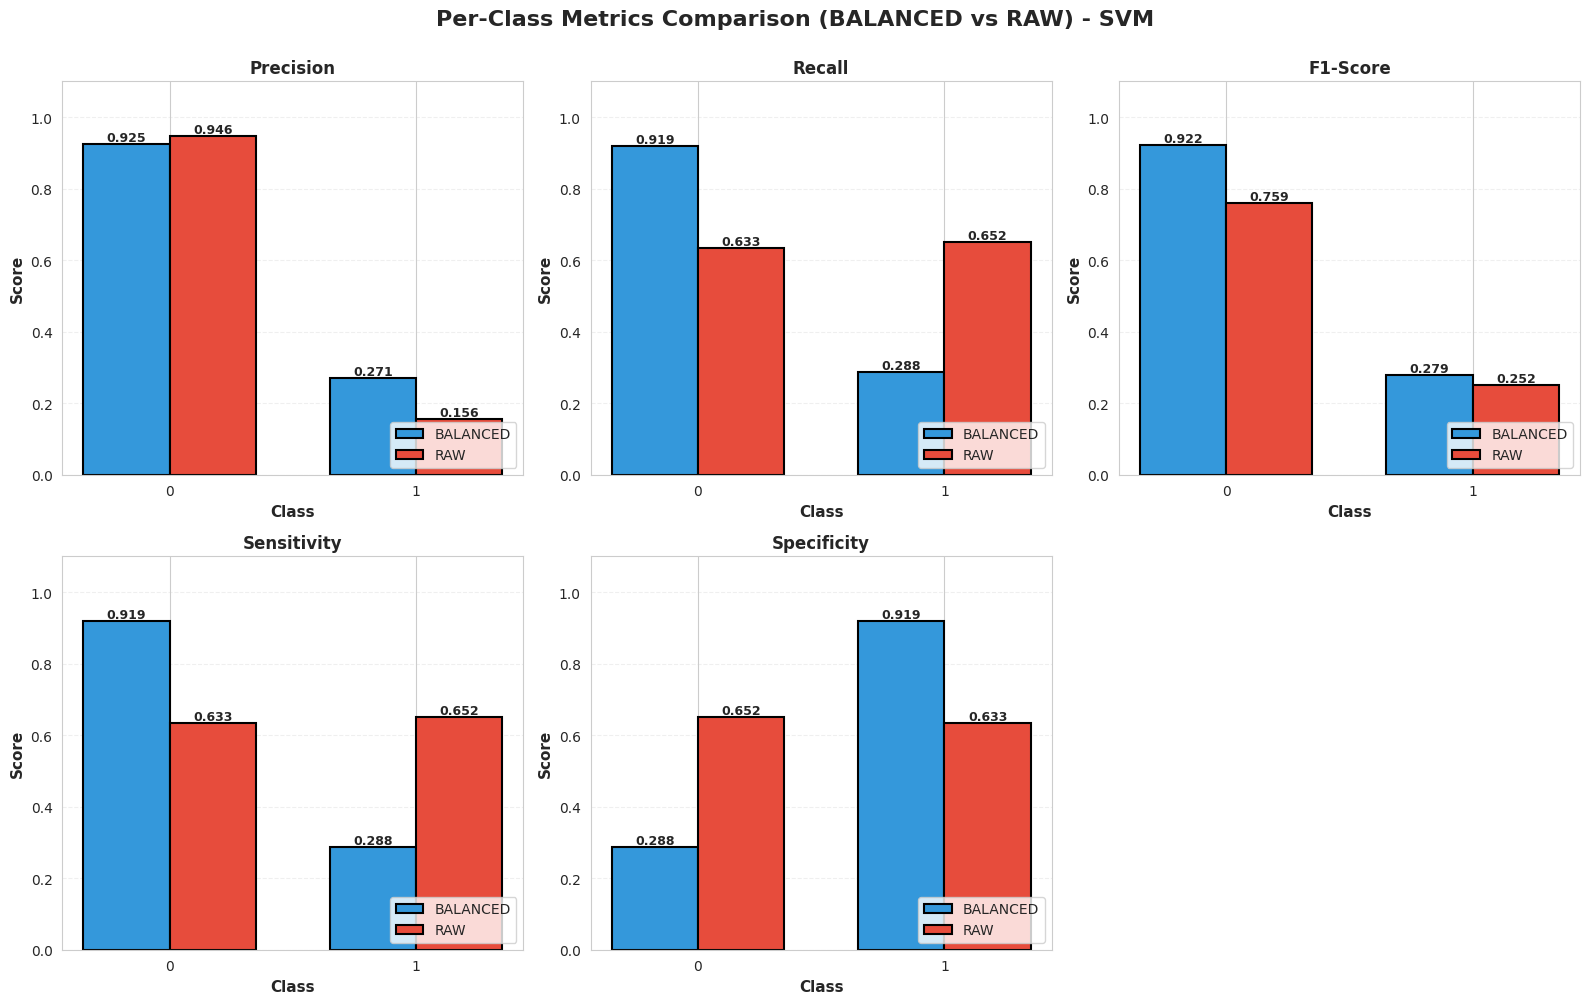

✓ Plot saved


In [18]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Per-Class Metrics Comparison (BALANCED vs RAW) - SVM', fontsize=16, fontweight='bold', y=1.00)

metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Sensitivity', 'Specificity']
colors_balanced = '#3498db'
colors_raw   = '#e74c3c'

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]

    if metric == 'Precision':
        balanced_data = prec_s; raw_data = prec_r
    elif metric == 'Recall':
        balanced_data = rec_s;  raw_data = rec_r
    elif metric == 'F1-Score':
        balanced_data = f1_s;   raw_data = f1_r
    elif metric == 'Sensitivity':
        balanced_data = sensitivity_s; raw_data = sensitivity_r
    else:  # Specificity
        balanced_data = specificity_s; raw_data = specificity_r

    x = np.arange(2)
    width = 0.35
    bars1 = ax.bar(x - width/2, balanced_data, width, label='BALANCED', color=colors_balanced, edgecolor='black', linewidth=1.5)
    bars2 = ax.bar(x + width/2, raw_data,   width, label='RAW',   color=colors_raw,   edgecolor='black', linewidth=1.5)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('Class', fontsize=11, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11, fontweight='bold')
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['0', '1'])
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim([0, 1.1])

# Eliminar el 6o subplot (bottom right) ya que solo tenemos 5 métricas
axes[1, 2].remove()

plt.tight_layout()
plt.show()
print("✓ Plot saved")

## 6. ROC Curves and AUC Analysis

ROC-AUC SCORES (Binary)
BALANCED AUC: 0.7574
RAW   AUC: 0.6822


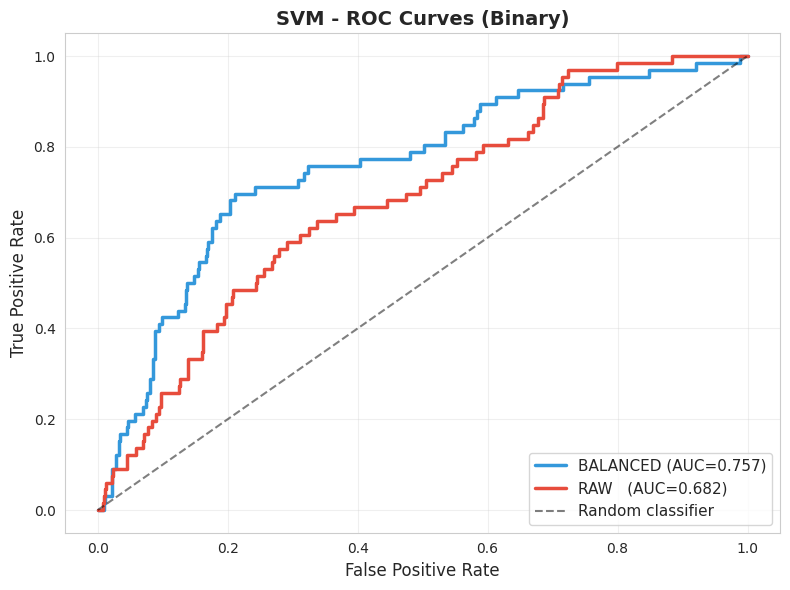

In [19]:
print("" + "="*70)
print("ROC-AUC SCORES (Binary)")
print("="*70)

# En clasificación binaria, evaluamos usando la probabilidad de la clase positiva (Clase 1)
proba_1_balanced = y_proba_balanced[:, 1]
proba_1_raw   = y_proba_raw[:, 1]

roc_auc_balanced = roc_auc_score(y_test, proba_1_balanced)
roc_auc_raw   = roc_auc_score(y_test, proba_1_raw)

print(f"BALANCED AUC: {roc_auc_balanced:.4f}")
print(f"RAW   AUC: {roc_auc_raw:.4f}")

# Generar un único gráfico para la curva ROC binaria
plt.figure(figsize=(8, 6))

fpr_s, tpr_s, _ = roc_curve(y_test, proba_1_balanced)
fpr_r, tpr_r, _ = roc_curve(y_test, proba_1_raw)

plt.plot(fpr_s, tpr_s, color='#3498db', lw=2.5, label=f'BALANCED (AUC={roc_auc_balanced:.3f})')
plt.plot(fpr_r, tpr_r, color='#e74c3c', lw=2.5, label=f'RAW   (AUC={roc_auc_raw:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random classifier')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('SVM - ROC Curves (Binary)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Confusion Matrices

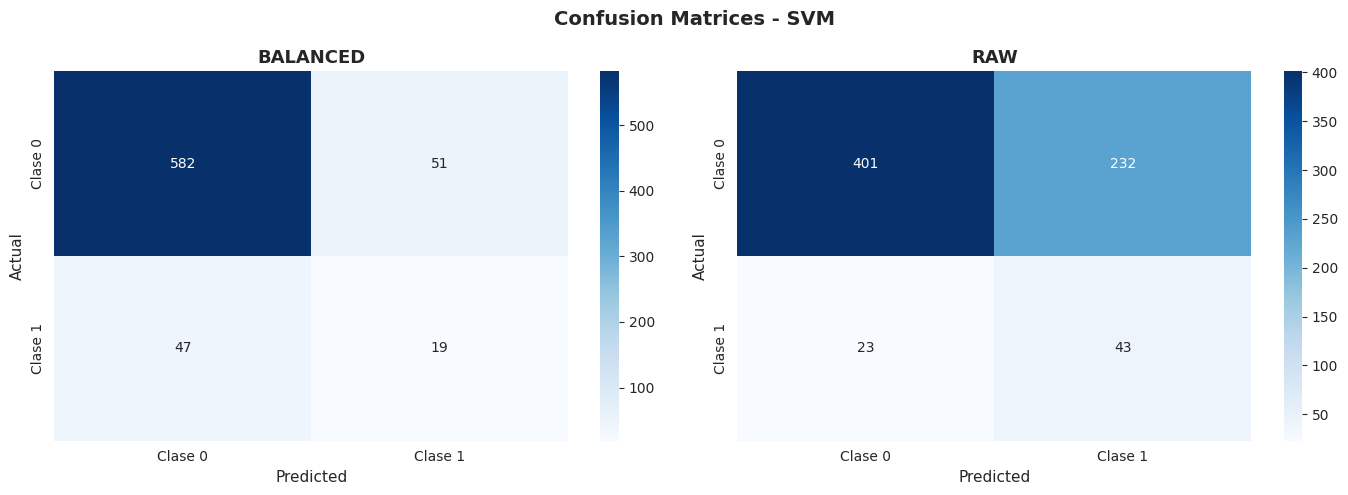

✓ Plot saved


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices - SVM', fontsize=14, fontweight='bold')

for ax, cm, title in zip(axes, [cm_balanced, cm_raw], ['BALANCED', 'RAW']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Clase 0', 'Clase 1'],
                yticklabels=['Clase 0', 'Clase 1'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.tight_layout()
plt.show()
print("✓ Plot saved")

## Save results to a file

In [21]:
print("" + "="*70)
print("6. FINAL COMPARISON")
print("-" * 80)

print("Class 0 (No Muere):")
print(f"  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}")
print(f"  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}")

print("\nClass 1 (Muere - Critical):")
print(f"  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {roc_auc_balanced:.4f}")
print(f"  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {roc_auc_raw:.4f}")

mean_recall_balanced = np.mean([rec_s[0], rec_s[1]])
mean_recall_raw   = np.mean([rec_r[0], rec_r[1]])

print(f"\nMean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}")
print(f"AUC:                 BALANCED={roc_auc_balanced:.4f}  |  RAW={roc_auc_raw:.4f}")

print("\n7. RECOMMENDATION")
print("-" * 80)
winner = "BALANCED" if mean_recall_balanced > mean_recall_raw else "RAW"
print(f"✅ RECOMMENDED MODEL: {winner}")
print("   (Higher average recall for mortality prediction)")
print("\nNote: Recall is prioritized for postoperative mortality risk prediction.")
print("      Detecting true deaths is more critical than avoiding false alarms.")
print("="*70)

timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
results_filename = RESULTS_PATH / f"evaluation_results_{timestamp}.txt"

# Parámetros propios de SVM
svm_params_keys = ['C', 'kernel', 'degree', 'gamma', 'class_weight', 'probability', 'random_state']
params_balanced_filtered = {k: v for k, v in model_balanced.get_params().items() if k in svm_params_keys}
params_raw_filtered   = {k: v for k, v in model_raw.get_params().items()   if k in svm_params_keys}

results_text = f"""
SVM MODEL EVALUATION RESULTS (BINARY: muere / no muere)
Timestamp: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
{'='*80}

0. MODEL HYPERPARAMETERS
{'-'*80}
BALANCED Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_balanced_filtered.items())}

RAW Model Parameters:
{chr(10).join(f"  {k}: {v}" for k, v in params_raw_filtered.items())}

1. OVERALL MODEL METRICS
{'-'*80}
{df_overall.to_string(index=False)}

2. PER-CLASS METRICS - BALANCED MODEL
{'-'*80}
{df_class_balanced.to_string(index=False)}

3. PER-CLASS METRICS - RAW MODEL
{'-'*80}
{df_class_raw.to_string(index=False)}

4. ROC-AUC SCORES (Binary)
{'-'*80}
BALANCED AUC: {roc_auc_balanced:.4f}
RAW   AUC: {roc_auc_raw:.4f}

5. CONFUSION MATRICES
{'-'*80}
BALANCED:
{cm_balanced}

RAW:
{cm_raw}

6. FINAL COMPARISON
{'-'*80}
Class 0 (No Muere):
  BALANCED - Recall: {rec_s[0]:.4f} | Sensitivity: {sensitivity_s[0]:.4f} | Specificity: {specificity_s[0]:.4f}
  RAW   - Recall: {rec_r[0]:.4f} | Sensitivity: {sensitivity_r[0]:.4f} | Specificity: {specificity_r[0]:.4f}

Class 1 (Muere - Critical):
  BALANCED - Recall: {rec_s[1]:.4f} | Sensitivity: {sensitivity_s[1]:.4f} | Specificity: {specificity_s[1]:.4f} | AUC: {roc_auc_balanced:.4f}
  RAW   - Recall: {rec_r[1]:.4f} | Sensitivity: {sensitivity_r[1]:.4f} | Specificity: {specificity_r[1]:.4f} | AUC: {roc_auc_raw:.4f}

Mean Recall (macro): BALANCED={mean_recall_balanced:.4f}  |  RAW={mean_recall_raw:.4f}
AUC:                 BALANCED={roc_auc_balanced:.4f}  |  RAW={roc_auc_raw:.4f}

7. RECOMMENDATION
{'-'*80}
✅ RECOMMENDED MODEL: {winner.upper()}
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for postoperative mortality risk prediction.
      Detecting true deaths is more critical than avoiding false alarms.
{'='*80}
"""

with open(results_filename, 'w') as f:
    f.write(results_text)

print(f"✓ Results saved → {results_filename.name}")
print(f"✅ Evaluation complete. Check {RESULTS_PATH} for all outputs.")


6. FINAL COMPARISON
--------------------------------------------------------------------------------
Class 0 (No Muere):
  BALANCED - Recall: 0.9194 | Sensitivity: 0.9194 | Specificity: 0.2879
  RAW   - Recall: 0.6335 | Sensitivity: 0.6335 | Specificity: 0.6515

Class 1 (Muere - Critical):
  BALANCED - Recall: 0.2879 | Sensitivity: 0.2879 | Specificity: 0.9194 | AUC: 0.7574
  RAW   - Recall: 0.6515 | Sensitivity: 0.6515 | Specificity: 0.6335 | AUC: 0.6822

Mean Recall (macro): BALANCED=0.6037  |  RAW=0.6425
AUC:                 BALANCED=0.7574  |  RAW=0.6822

7. RECOMMENDATION
--------------------------------------------------------------------------------
✅ RECOMMENDED MODEL: RAW
   (Higher average recall for mortality prediction)

Note: Recall is prioritized for postoperative mortality risk prediction.
      Detecting true deaths is more critical than avoiding false alarms.
✓ Results saved → evaluation_results_2026-05-14_14-38-07.txt
✅ Evaluation complete. Check /home/pablo/Desktop/E